Bài tập về nhà
Mục tiêu: hiểu sâu hơn về ảnh hưởng của kiến trúc, loss function, optimizer.

Nộp file [HọTên]_ANN_Homework.ipynb. Mỗi câu cần có code + Markdown giải thích.

Phần 1: Thay đổi cấu trúc ANN
Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.
So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?
Gợi ý: viết hàm train(model, epochs) trả về (loss_history, acc_history) để gọi 3 lần cho gọn.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

### 1. Tạo tập dữ liệu giả lập

Chúng ta sẽ sử dụng tập dữ liệu `make_moons` từ `sklearn.datasets` để tạo một bài toán phân loại nhị phân không tuyến tính, phù hợp để thử nghiệm ANN.

In [20]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Training data shape: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Testing data shape: {X_test_tensor.shape}, {y_test_tensor.shape}")

Training data shape: torch.Size([800, 2]), torch.Size([800, 1])
Testing data shape: torch.Size([200, 2]), torch.Size([200, 1])


### 2. Định nghĩa kiến trúc ANN cơ bản (4 nút ẩn)

In [21]:
class ANN_4_nodes(nn.Module):
    def __init__(self):
        super(ANN_4_nodes, self).__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

### 3. Định nghĩa hàm `train`

Hàm này sẽ huấn luyện mô hình và trả về lịch sử loss và accuracy.

In [27]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=500, learning_rate=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):

        outputs = model(X_train)
        loss = criterion(outputs, y_train)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        with torch.no_grad():

            train_predicted = (model(X_train) > 0.5).float()
            train_accuracy = (train_predicted == y_train).float().mean()
            train_acc_history.append(train_accuracy.item())


            test_predicted = (model(X_test) > 0.5).float()
            test_accuracy = (test_predicted == y_test).float().mean()
            test_acc_history.append(test_accuracy.item())

        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_accuracy.item():.4f}, Test Acc: {test_accuracy.item():.4f}')

    return loss_history, train_acc_history, test_acc_history

### 4. Huấn luyện và đánh giá mô hình 4 nút ẩn

In [23]:
model_4_nodes = ANN_4_nodes()
print("Model 4 nodes architecture:")
print(model_4_nodes)

loss_history_4, train_acc_history_4, test_acc_history_4 = train_model(
    model_4_nodes, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_4 = loss_history_4[-1]
final_test_acc_4 = test_acc_history_4[-1]

print(f"\nFinal Loss (4 nodes): {final_loss_4:.4f}")
print(f"Final Test Accuracy (4 nodes): {final_test_acc_4:.4f}")

Model 4 nodes architecture:
ANN_4_nodes(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch [100/500], Loss: 0.2742, Train Acc: 0.8763, Test Acc: 0.8850
Epoch [200/500], Loss: 0.2448, Train Acc: 0.8813, Test Acc: 0.8850
Epoch [300/500], Loss: 0.2262, Train Acc: 0.8863, Test Acc: 0.8750
Epoch [400/500], Loss: 0.2138, Train Acc: 0.8888, Test Acc: 0.8850
Epoch [500/500], Loss: 0.2088, Train Acc: 0.8975, Test Acc: 0.8900

Final Loss (4 nodes): 0.2088
Final Test Accuracy (4 nodes): 0.8900


In [24]:
class ANN_8_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_nodes, self).__init__()
        self.layer1 = nn.Linear(2, 8) # 2 input features, 8 hidden nodes
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1) # 8 hidden nodes, 1 output node
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

model_8_nodes = ANN_8_nodes()
print("Model 8 nodes architecture:")
print(model_8_nodes)

loss_history_8, train_acc_history_8, test_acc_history_8 = train_model(
    model_8_nodes, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_8 = loss_history_8[-1]
final_test_acc_8 = test_acc_history_8[-1]

print(f"\nFinal Loss (8 nodes): {final_loss_8:.4f}")
print(f"Final Test Accuracy (8 nodes): {final_test_acc_8:.4f}")

Model 8 nodes architecture:
ANN_8_nodes(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch [100/500], Loss: 0.2426, Train Acc: 0.8850, Test Acc: 0.9000
Epoch [200/500], Loss: 0.1655, Train Acc: 0.9312, Test Acc: 0.9550
Epoch [300/500], Loss: 0.0730, Train Acc: 0.9812, Test Acc: 0.9900
Epoch [400/500], Loss: 0.0401, Train Acc: 0.9925, Test Acc: 1.0000
Epoch [500/500], Loss: 0.0271, Train Acc: 0.9962, Test Acc: 1.0000

Final Loss (8 nodes): 0.0271
Final Test Accuracy (8 nodes): 1.0000


In [25]:
class ANN_8_6_nodes(nn.Module):
    def __init__(self):
        super(ANN_8_6_nodes, self).__init__()
        self.layer1 = nn.Linear(2, 8)  # Input to first hidden layer
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)  # First hidden layer to second hidden layer
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)  # Second hidden layer to output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        return x

model_8_6_nodes = ANN_8_6_nodes()
print("Model 8+6 nodes architecture:")
print(model_8_6_nodes)

loss_history_8_6, train_acc_history_8_6, test_acc_history_8_6 = train_model(
    model_8_6_nodes, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_8_6 = loss_history_8_6[-1]
final_test_acc_8_6 = test_acc_history_8_6[-1]

print(f"\nFinal Loss (8+6 nodes): {final_loss_8_6:.4f}")
print(f"Final Test Accuracy (8+6 nodes): {final_test_acc_8_6:.4f}")

Model 8+6 nodes architecture:
ANN_8_6_nodes(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=6, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch [100/500], Loss: 0.2230, Train Acc: 0.8963, Test Acc: 0.9150
Epoch [200/500], Loss: 0.0189, Train Acc: 0.9962, Test Acc: 1.0000
Epoch [300/500], Loss: 0.0058, Train Acc: 1.0000, Test Acc: 1.0000
Epoch [400/500], Loss: 0.0031, Train Acc: 1.0000, Test Acc: 1.0000
Epoch [500/500], Loss: 0.0020, Train Acc: 1.0000, Test Acc: 1.0000

Final Loss (8+6 nodes): 0.0020
Final Test Accuracy (8+6 nodes): 1.0000


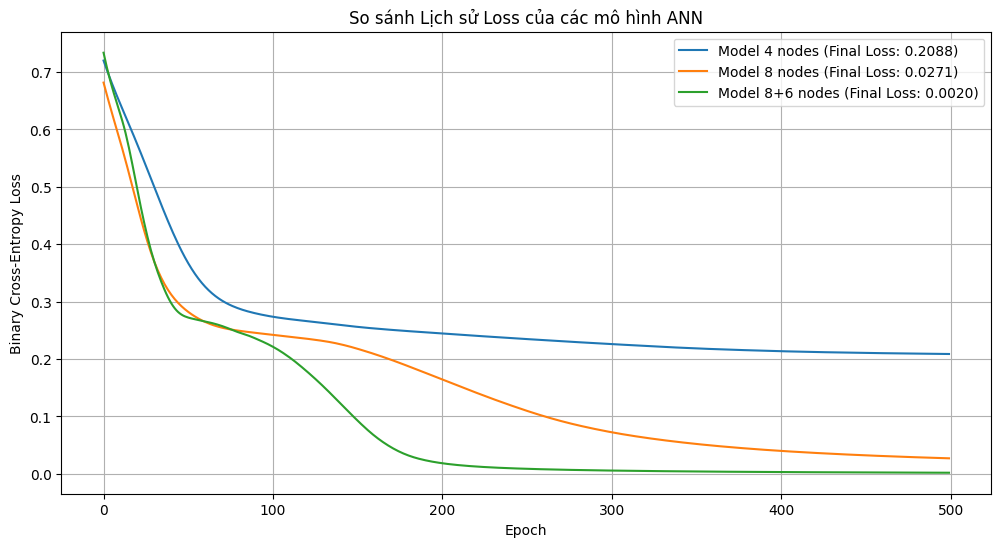

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(loss_history_4, label=f'Model 4 nodes (Final Loss: {final_loss_4:.4f})')
plt.plot(loss_history_8, label=f'Model 8 nodes (Final Loss: {final_loss_8:.4f})')
plt.plot(loss_history_8_6, label=f'Model 8+6 nodes (Final Loss: {final_loss_8_6:.4f})')
plt.title('So sánh Lịch sử Loss của các mô hình ANN')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

##Mô hình to hơn có giảm loss nhanh hơn không?

Có
##Có overfitting không?

Không có dấu hiệu overfitting đáng kể
##Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?

Có, đối với độ chính xác


Phần 2: Loss và Optimizer
Đổi BCELoss thành BCEWithLogitsLoss: bỏ nn.Sigmoid khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần torch.sigmoid(output) > 0.5 chứ không phải output > 0.5.

Gợi ý: BCEWithLogitsLoss ổn định số học hơn vì gộp sigmoid + log thành một phép tính log(1 + exp(-x)) (log-sum-exp trick), tránh tràn số khi
 lớn.

Đổi Adam thành SGD (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.

In [28]:
class ANN_4_nodes_no_sigmoid(nn.Module):
    def __init__(self):
        super(ANN_4_nodes_no_sigmoid, self).__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 1) # No Sigmoid here

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

class ANN_8_nodes_no_sigmoid(nn.Module):
    def __init__(self):
        super(ANN_8_nodes_no_sigmoid, self).__init__()
        self.layer1 = nn.Linear(2, 8) # 2 input features, 8 hidden nodes
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1) # 8 hidden nodes, 1 output node (no Sigmoid)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

class ANN_8_6_nodes_no_sigmoid(nn.Module):
    def __init__(self):
        super(ANN_8_6_nodes_no_sigmoid, self).__init__()
        self.layer1 = nn.Linear(2, 8)  # Input to first hidden layer
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)  # First hidden layer to second hidden layer
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)  # Second hidden layer to output (no Sigmoid)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        return x

### 2. Định nghĩa hàm `train_model_bce_logits` với `BCEWithLogitsLoss`

Hàm huấn luyện này sẽ sử dụng `nn.BCEWithLogitsLoss` và điều chỉnh logic dự đoán bằng cách áp dụng `torch.sigmoid` trước khi so sánh với ngưỡng 0.5.

In [29]:
def train_model_bce_logits(model, X_train, y_train, X_test, y_test, epochs=500, learning_rate=0.01):
    criterion = nn.BCEWithLogitsLoss() # Sử dụng BCEWithLogitsLoss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):
        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        with torch.no_grad():
            # Apply sigmoid to outputs for accuracy calculation
            train_predicted = (torch.sigmoid(model(X_train)) > 0.5).float()
            train_accuracy = (train_predicted == y_train).float().mean()
            train_acc_history.append(train_accuracy.item())

            test_predicted = (torch.sigmoid(model(X_test)) > 0.5).float()
            test_accuracy = (test_predicted == y_test).float().mean()
            test_acc_history.append(test_accuracy.item())

        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_accuracy.item():.4f}, Test Acc: {test_accuracy.item():.4f}')

    return loss_history, train_acc_history, test_acc_history

### 3. Huấn luyện và đánh giá các mô hình với `BCEWithLogitsLoss` (Optimizer: Adam)

Chúng ta sẽ huấn luyện ba mô hình với kiến trúc tương tự như phần 1 nhưng sử dụng `BCEWithLogitsLoss`.

In [30]:
# Huấn luyện Model 4 nodes với BCEWithLogitsLoss
model_4_nodes_bce_logits = ANN_4_nodes_no_sigmoid()
print("\nModel 4 nodes (BCEWithLogitsLoss) architecture:")
print(model_4_nodes_bce_logits)

loss_history_4_bce, train_acc_history_4_bce, test_acc_history_4_bce = train_model_bce_logits(
    model_4_nodes_bce_logits, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_4_bce = loss_history_4_bce[-1]
final_test_acc_4_bce = test_acc_history_4_bce[-1]

print(f"\nFinal Loss (4 nodes, BCEWithLogitsLoss): {final_loss_4_bce:.4f}")
print(f"Final Test Accuracy (4 nodes, BCEWithLogitsLoss): {final_test_acc_4_bce:.4f}")


Model 4 nodes (BCEWithLogitsLoss) architecture:
ANN_4_nodes_no_sigmoid(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)
Epoch [100/500], Loss: 0.2678, Train Acc: 0.8725, Test Acc: 0.8650
Epoch [200/500], Loss: 0.2236, Train Acc: 0.9100, Test Acc: 0.9100
Epoch [300/500], Loss: 0.1660, Train Acc: 0.9312, Test Acc: 0.9450
Epoch [400/500], Loss: 0.0963, Train Acc: 0.9712, Test Acc: 0.9750
Epoch [500/500], Loss: 0.0511, Train Acc: 0.9937, Test Acc: 1.0000

Final Loss (4 nodes, BCEWithLogitsLoss): 0.0511
Final Test Accuracy (4 nodes, BCEWithLogitsLoss): 1.0000


In [31]:
# Huấn luyện Model 8 nodes với BCEWithLogitsLoss
model_8_nodes_bce_logits = ANN_8_nodes_no_sigmoid()
print("\nModel 8 nodes (BCEWithLogitsLoss) architecture:")
print(model_8_nodes_bce_logits)

loss_history_8_bce, train_acc_history_8_bce, test_acc_history_8_bce = train_model_bce_logits(
    model_8_nodes_bce_logits, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_8_bce = loss_history_8_bce[-1]
final_test_acc_8_bce = test_acc_history_8_bce[-1]

print(f"\nFinal Loss (8 nodes, BCEWithLogitsLoss): {final_loss_8_bce:.4f}")
print(f"Final Test Accuracy (8 nodes, BCEWithLogitsLoss): {final_test_acc_8_bce:.4f}")


Model 8 nodes (BCEWithLogitsLoss) architecture:
ANN_8_nodes_no_sigmoid(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)
Epoch [100/500], Loss: 0.2412, Train Acc: 0.8863, Test Acc: 0.8850
Epoch [200/500], Loss: 0.1696, Train Acc: 0.9250, Test Acc: 0.9350
Epoch [300/500], Loss: 0.0822, Train Acc: 0.9775, Test Acc: 0.9850
Epoch [400/500], Loss: 0.0401, Train Acc: 0.9912, Test Acc: 0.9950
Epoch [500/500], Loss: 0.0235, Train Acc: 0.9962, Test Acc: 1.0000

Final Loss (8 nodes, BCEWithLogitsLoss): 0.0235
Final Test Accuracy (8 nodes, BCEWithLogitsLoss): 1.0000


In [32]:
# Huấn luyện Model 8+6 nodes với BCEWithLogitsLoss
model_8_6_nodes_bce_logits = ANN_8_6_nodes_no_sigmoid()
print("\nModel 8+6 nodes (BCEWithLogitsLoss) architecture:")
print(model_8_6_nodes_bce_logits)

loss_history_8_6_bce, train_acc_history_8_6_bce, test_acc_history_8_6_bce = train_model_bce_logits(
    model_8_6_nodes_bce_logits, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500
)

final_loss_8_6_bce = loss_history_8_6_bce[-1]
final_test_acc_8_6_bce = test_acc_history_8_6_bce[-1]

print(f"\nFinal Loss (8+6 nodes, BCEWithLogitsLoss): {final_loss_8_6_bce:.4f}")
print(f"Final Test Accuracy (8+6 nodes, BCEWithLogitsLoss): {final_test_acc_8_6_bce:.4f}")


Model 8+6 nodes (BCEWithLogitsLoss) architecture:
ANN_8_6_nodes_no_sigmoid(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=6, out_features=1, bias=True)
)
Epoch [100/500], Loss: 0.2040, Train Acc: 0.9862, Test Acc: 0.9900
Epoch [200/500], Loss: 0.0796, Train Acc: 1.0000, Test Acc: 1.0000
Epoch [300/500], Loss: 0.0457, Train Acc: 1.0000, Test Acc: 1.0000
Epoch [400/500], Loss: 0.0303, Train Acc: 1.0000, Test Acc: 1.0000
Epoch [500/500], Loss: 0.0218, Train Acc: 1.0000, Test Acc: 1.0000

Final Loss (8+6 nodes, BCEWithLogitsLoss): 0.0218
Final Test Accuracy (8+6 nodes, BCEWithLogitsLoss): 1.0000


### 4. So sánh Lịch sử Loss của các mô hình với `BCEWithLogitsLoss`

Biểu đồ sau đây so sánh lịch sử loss của ba mô hình khi sử dụng `BCEWithLogitsLoss` và optimizer `Adam`.

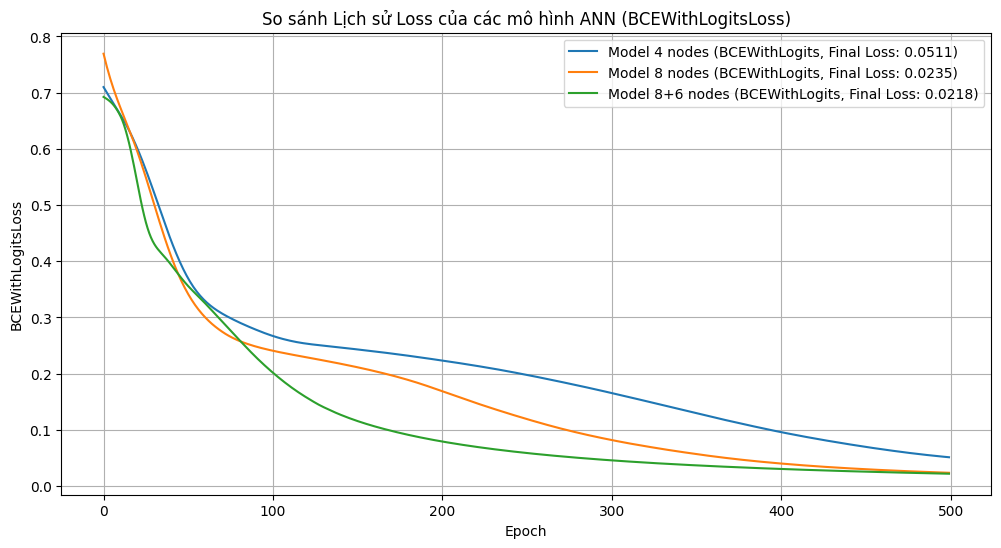

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(loss_history_4_bce, label=f'Model 4 nodes (BCEWithLogits, Final Loss: {final_loss_4_bce:.4f})')
plt.plot(loss_history_8_bce, label=f'Model 8 nodes (BCEWithLogits, Final Loss: {final_loss_8_bce:.4f})')
plt.plot(loss_history_8_6_bce, label=f'Model 8+6 nodes (BCEWithLogits, Final Loss: {final_loss_8_6_bce:.4f})')
plt.title('So sánh Lịch sử Loss của các mô hình ANN (BCEWithLogitsLoss)')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.legend()
plt.grid(True)
plt.show()

### 5. Định nghĩa hàm `train_model_sgd` với Optimizer SGD

Bây giờ, chúng ta sẽ định nghĩa một hàm huấn luyện mới sử dụng `optim.SGD` thay vì `Adam` để so sánh tốc độ hội tụ.

In [34]:
def train_model_sgd(model, X_train, y_train, X_test, y_test, epochs=500, learning_rate=0.01, momentum=0.9):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
    loss_history = []
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):
        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        with torch.no_grad():
            # Apply sigmoid to outputs for accuracy calculation
            train_predicted = (torch.sigmoid(model(X_train)) > 0.5).float()
            train_accuracy = (train_predicted == y_train).float().mean()
            train_acc_history.append(train_accuracy.item())

            test_predicted = (torch.sigmoid(model(X_test)) > 0.5).float()
            test_accuracy = (test_predicted == y_test).float().mean()
            test_acc_history.append(test_accuracy.item())

        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_accuracy.item():.4f}, Test Acc: {test_accuracy.item():.4f}')

    return loss_history, train_acc_history, test_acc_history

### 6. Huấn luyện và đánh giá mô hình 4 nút ẩn với Optimizer SGD

Chúng ta sẽ huấn luyện mô hình `ANN_4_nodes_no_sigmoid` với optimizer `SGD` và so sánh với phiên bản đã huấn luyện bằng `Adam`.

In [35]:
# Huấn luyện Model 4 nodes (BCEWithLogitsLoss) với SGD
model_4_nodes_sgd = ANN_4_nodes_no_sigmoid()
print("\nModel 4 nodes (BCEWithLogitsLoss, SGD) architecture:")
print(model_4_nodes_sgd)

loss_history_4_sgd, train_acc_history_4_sgd, test_acc_history_4_sgd = train_model_sgd(
    model_4_nodes_sgd, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=500, learning_rate=0.01, momentum=0.9
)

final_loss_4_sgd = loss_history_4_sgd[-1]
final_test_acc_4_sgd = test_acc_history_4_sgd[-1]

print(f"\nFinal Loss (4 nodes, BCEWithLogitsLoss, SGD): {final_loss_4_sgd:.4f}")
print(f"Final Test Accuracy (4 nodes, BCEWithLogitsLoss, SGD): {final_test_acc_4_sgd:.4f}")


Model 4 nodes (BCEWithLogitsLoss, SGD) architecture:
ANN_4_nodes_no_sigmoid(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)
Epoch [100/500], Loss: 0.2803, Train Acc: 0.8700, Test Acc: 0.8600
Epoch [200/500], Loss: 0.2596, Train Acc: 0.8813, Test Acc: 0.8700
Epoch [300/500], Loss: 0.2569, Train Acc: 0.8788, Test Acc: 0.8750
Epoch [400/500], Loss: 0.2553, Train Acc: 0.8788, Test Acc: 0.8750
Epoch [500/500], Loss: 0.2539, Train Acc: 0.8800, Test Acc: 0.8750

Final Loss (4 nodes, BCEWithLogitsLoss, SGD): 0.2539
Final Test Accuracy (4 nodes, BCEWithLogitsLoss, SGD): 0.8750


### 7. So sánh Lịch sử Loss của các Optimizer (Adam vs. SGD)

Biểu đồ sau đây so sánh lịch sử loss của mô hình 4 nút ẩn khi sử dụng optimizer `Adam` và `SGD`.

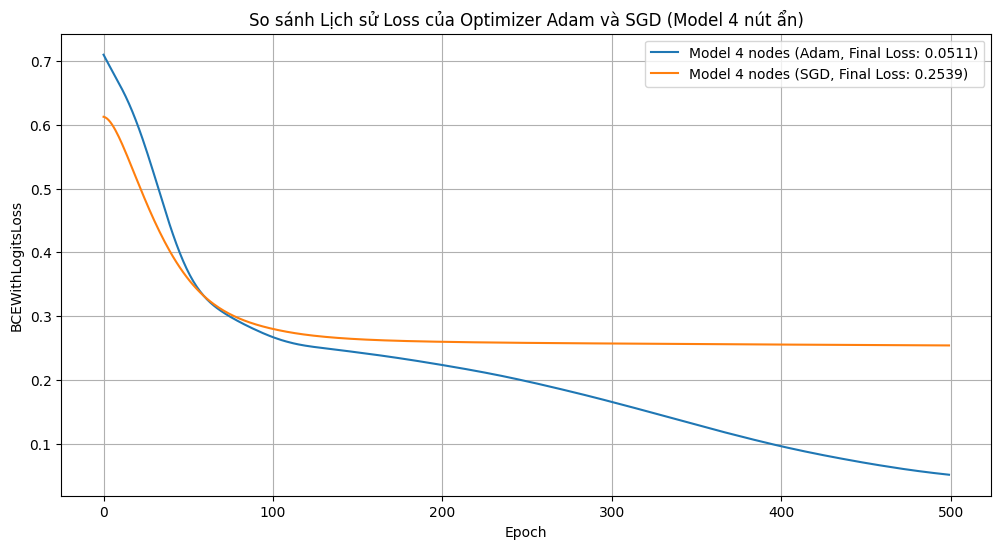

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(loss_history_4_bce, label=f'Model 4 nodes (Adam, Final Loss: {final_loss_4_bce:.4f})')
plt.plot(loss_history_4_sgd, label=f'Model 4 nodes (SGD, Final Loss: {final_loss_4_sgd:.4f})')
plt.title('So sánh Lịch sử Loss của Optimizer Adam và SGD (Model 4 nút ẩn)')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.legend()
plt.grid(True)
plt.show()

Phần 3: Phân tích sâu
Thử 3 learning rate: lr ∈ {0.001, 0.01, 0.1} với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:

lr nào quá nhỏ → học chậm?
lr nào quá lớn → loss dao động hoặc nổ?
Vẽ ranh giới quyết định ở các epoch 10, 100, 500. Em nên thấy boundary từ thẳng dần dần thành cong tròn.